### Importación de datos



In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [ ]:
# Veamos la estructura de los datos
print("📦 ESTRUCTURA DE LOS DATOS")
print("="*50)
print("\nColumnas disponibles:")
print(tienda.columns.tolist())

print("\n📊 Información del dataset:")
print(tienda.info())

print("\n🔢 Primeras filas:")
print(tienda.head())

print("\n📈 Estadísticas básicas:")
print(tienda.describe())

📦 ESTRUCTURA DE LOS DATOS

Columnas disponibles:
['Producto', 'Categoría del Producto', 'Precio', 'Costo de envío', 'Fecha de Compra', 'Vendedor', 'Lugar de Compra', 'Calificación', 'Método de pago', 'Cantidad de cuotas', 'lat', 'lon']

📊 Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                2359 non-null   object 
 1   Categoría del Producto  2359 non-null   object 
 2   Precio                  2359 non-null   float64
 3   Costo de envío          2359 non-null   float64
 4   Fecha de Compra         2359 non-null   object 
 5   Vendedor                2359 non-null   object 
 6   Lugar de Compra         2359 non-null   object 
 7   Calificación            2359 non-null   int64  
 8   Método de pago          2359 non-null   object 
 9   Cantidad de cuotas      2359 non-null   i

In [ ]:
# Agregar columna identificadora a cada tienda
print("🏪 IDENTIFICANDO LAS TIENDAS")
print("="*50)

# Agregar columna 'Tienda' a cada DataFrame
tienda['Tienda'] = 'Tienda 1'
tienda2['Tienda'] = 'Tienda 2'
tienda3['Tienda'] = 'Tienda 3'
tienda4['Tienda'] = 'Tienda 4'

# Ahora sí, unir todas
df_completo = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

print(f"✅ Total de registros: {len(df_completo)}")
print(f"\n📊 Registros por tienda:")
print(df_completo['Tienda'].value_counts())

# Veamos un resumen rápido
print("\n📍 Lugares de compra en cada tienda:")
for tienda_num in ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']:
    lugares = df_completo[df_completo['Tienda'] == tienda_num]['Lugar de Compra'].unique()
    print(f"{tienda_num}: {lugares}")

🏪 IDENTIFICANDO LAS TIENDAS
✅ Total de registros: 9435

📊 Registros por tienda:
Tienda
Tienda 1    2359
Tienda 2    2359
Tienda 3    2359
Tienda 4    2358
Name: count, dtype: int64

📍 Lugares de compra en cada tienda:
Tienda 1: ['Bogotá' 'Medellín' 'Cartagena' 'Cali' 'Santa Marta' 'Pereira'
 'Barranquilla' 'Villavicencio' 'Inírida' 'Cúcuta' 'Manizales' 'Neiva'
 'Bucaramanga' 'Valledupar' 'Pasto' 'Riohacha' 'Armenia' 'Leticia'
 'Soacha']
Tienda 2: ['Medellín' 'Pereira' 'Cali' 'Bogotá' 'Leticia' 'Barranquilla' 'Cúcuta'
 'Riohacha' 'Santa Marta' 'Valledupar' 'Bucaramanga' 'Manizales'
 'Cartagena' 'Pasto' 'Armenia' 'Neiva' 'Villavicencio' 'Soacha' 'Inírida']
Tienda 3: ['Santa Marta' 'Cali' 'Bogotá' 'Barranquilla' 'Medellín' 'Neiva' 'Cúcuta'
 'Bucaramanga' 'Cartagena' 'Pereira' 'Riohacha' 'Pasto' 'Villavicencio'
 'Leticia' 'Armenia' 'Manizales' 'Soacha' 'Valledupar' 'Inírida']
Tienda 4: ['Bogotá' 'Cúcuta' 'Medellín' 'Cartagena' 'Manizales' 'Leticia'
 'Bucaramanga' 'Cali' 'Riohacha' 'Pasto' 

In [ ]:
# ============================================================
# ANÁLISIS 1: FACTURACIÓN TOTAL POR TIENDA
# ============================================================

print("💰 ANÁLISIS DE INGRESOS TOTALES")
print("="*60)

# Paso 1: Calcular ingresos totales por tienda
ingresos_por_tienda = df_completo.groupby('Tienda')['Precio'].sum()

print("\n📈 Ingresos totales de cada tienda:")
print(ingresos_por_tienda)

# Paso 2: Ordenar de mayor a menor
ingresos_ordenados = ingresos_por_tienda.sort_values(ascending=False)

print("\n🏆 Ranking de tiendas por ingresos:")
for i, (tienda, ingreso) in enumerate(ingresos_ordenados.items(), 1):
    print(f"{i}. {tienda}: ${ingreso:,.0f}")

# Paso 3: Identificar la tienda con MENOS ingresos
tienda_menos_ingresos = ingresos_ordenados.idxmin()
ingreso_minimo = ingresos_ordenados.min()

print(f"\n⚠️  Tienda con MENORES ingresos: {tienda_menos_ingresos}")
print(f"   Ingresos: ${ingreso_minimo:,.0f}")

💰 ANÁLISIS DE INGRESOS TOTALES

📈 Ingresos totales de cada tienda:
Tienda
Tienda 1    1.150880e+09
Tienda 2    1.116344e+09
Tienda 3    1.098020e+09
Tienda 4    1.038376e+09
Name: Precio, dtype: float64

🏆 Ranking de tiendas por ingresos:
1. Tienda 1: $1,150,880,400
2. Tienda 2: $1,116,343,500
3. Tienda 3: $1,098,019,600
4. Tienda 4: $1,038,375,700

⚠️  Tienda con MENORES ingresos: Tienda 4
   Ingresos: $1,038,375,700


# 2. Ventas por categoría

In [ ]:
# ============================================================
# ANÁLISIS 2: VENTAS POR CATEGORÍA EN CADA TIENDA
# ============================================================

print("📦 ANÁLISIS DE VENTAS POR CATEGORÍA")
print("="*60)

# Paso 1: Ver todas las categorías disponibles
print("\n🏷️ Categorías de productos disponibles:")
print(df_completo['Categoría del Producto'].unique())

# Paso 2: Contar ventas por categoría en cada tienda
ventas_por_categoria = df_completo.groupby(['Tienda', 'Categoría del Producto']).size()

print("\n📊 Ventas por categoría en cada tienda:")
print(ventas_por_categoria)

# Paso 3: Analizar cada tienda individualmente
print("\n" + "="*60)
for tienda_num in ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']:
    print(f"\n🏪 {tienda_num}")
    print("-" * 40)

    # Filtrar datos de esta tienda
    datos_tienda = df_completo[df_completo['Tienda'] == tienda_num]

    # Contar ventas por categoría
    ventas_categoria = datos_tienda['Categoría del Producto'].value_counts()

    print(ventas_categoria)
    print(f"\n🥇 Categoría MÁS vendida: {ventas_categoria.index[0]} ({ventas_categoria.iloc[0]} ventas)")
    print(f"🥉 Categoría MENOS vendida: {ventas_categoria.index[-1]} ({ventas_categoria.iloc[-1]} ventas)")

📦 ANÁLISIS DE VENTAS POR CATEGORÍA

🏷️ Categorías de productos disponibles:
['Electrónicos' 'Muebles' 'Juguetes' 'Electrodomésticos'
 'Artículos para el hogar' 'Deportes y diversión' 'Libros'
 'Instrumentos musicales']

📊 Ventas por categoría en cada tienda:
Tienda    Categoría del Producto 
Tienda 1  Artículos para el hogar    171
          Deportes y diversión       284
          Electrodomésticos          312
          Electrónicos               448
          Instrumentos musicales     182
          Juguetes                   324
          Libros                     173
          Muebles                    465
Tienda 2  Artículos para el hogar    181
          Deportes y diversión       275
          Electrodomésticos          305
          Electrónicos               422
          Instrumentos musicales     224
          Juguetes                   313
          Libros                     197
          Muebles                    442
Tienda 3  Artículos para el hogar    177
          

# 3. Calificación promedio de la tienda


In [ ]:
# ============================================================
# ANÁLISIS 3: CALIFICACIÓN PROMEDIO POR TIENDA
# ============================================================

print("⭐ ANÁLISIS DE CALIFICACIONES PROMEDIO")
print("="*60)

# Paso 1: Calcular la calificación promedio por tienda
calificacion_promedio_por_tienda = df_completo.groupby('Tienda')['Calificación'].mean()

print("\n📈 Calificación promedio de cada tienda:")
print(calificacion_promedio_por_tienda)

# Paso 2: Ordenar de mayor a menor
calificaciones_ordenadas = calificacion_promedio_por_tienda.sort_values(ascending=False)

print("\n🏆 Ranking de tiendas por calificación promedio:")
for i, (tienda, calificacion) in enumerate(calificaciones_ordenadas.items(), 1):
    print(f"{i}. {tienda}: {calificacion:.2f}")

# Paso 3: Identificar la tienda con la MEJOR y PEOR calificación
tienda_mejor_calificacion = calificaciones_ordenadas.idxmax()
calificacion_maxima = calificaciones_ordenadas.max()

tienda_peor_calificacion = calificaciones_ordenadas.idxmin()
calificacion_minima = calificaciones_ordenadas.min()

print(f"\n🌟 Tienda con la MEJOR calificación promedio: {tienda_mejor_calificacion} ({calificacion_maxima:.2f})")
print(f"💔 Tienda con la PEOR calificación promedio: {tienda_peor_calificacion} ({calificacion_minima:.2f})")

⭐ ANÁLISIS DE CALIFICACIONES PROMEDIO

📈 Calificación promedio de cada tienda:
Tienda
Tienda 1    3.976685
Tienda 2    4.037304
Tienda 3    4.048326
Tienda 4    3.995759
Name: Calificación, dtype: float64

🏆 Ranking de tiendas por calificación promedio:
1. Tienda 3: 4.05
2. Tienda 2: 4.04
3. Tienda 4: 4.00
4. Tienda 1: 3.98

🌟 Tienda con la MEJOR calificación promedio: Tienda 3 (4.05)
💔 Tienda con la PEOR calificación promedio: Tienda 1 (3.98)


## 4. Productos más y menos vendidos

📈 ANÁLISIS DE PRODUCTOS MÁS Y MENOS VENDIDOS POR TIENDA

🏪 Tienda 1
----------------------------------------
🥇 Productos más vendidos en Tienda 1:
  Tienda         Producto  Cantidad_Vendida
Tienda 1          Armario                60
Tienda 1    TV LED UHD 4K                60
Tienda 1       Microondas                60
Tienda 1 Secadora de ropa                58
Tienda 1    Mesa de noche                56
🥉 Productos menos vendidos en Tienda 1:
  Tienda                  Producto  Cantidad_Vendida
Tienda 1                   Mochila                39
Tienda 1                 Pandereta                36
Tienda 1           Olla de presión                35
Tienda 1              Celular ABXY                33
Tienda 1 Auriculares con micrófono                33


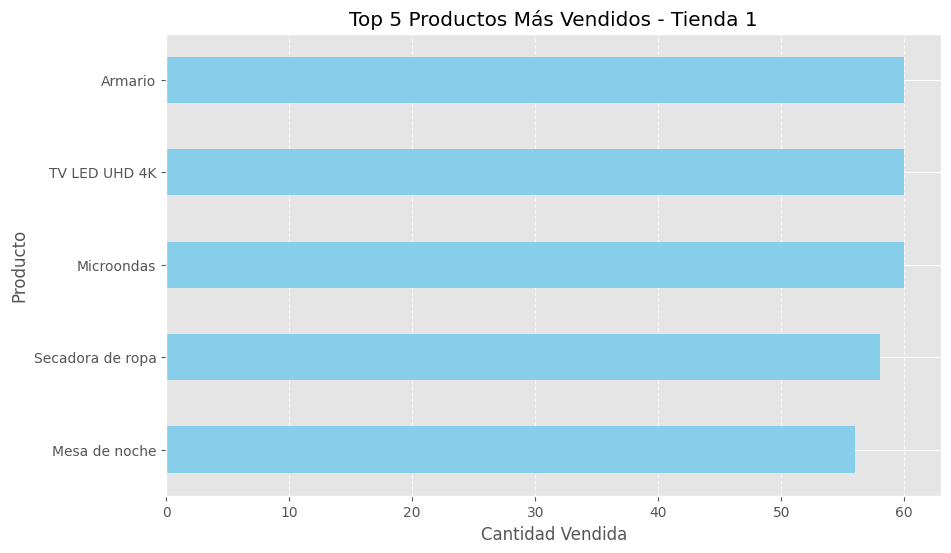

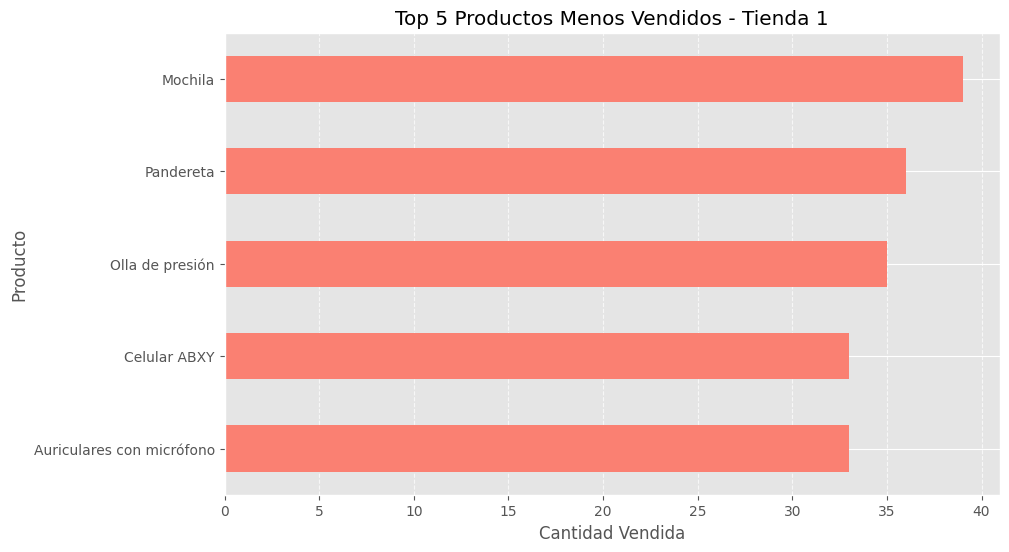


🏪 Tienda 2
----------------------------------------
🥇 Productos más vendidos en Tienda 2:
  Tienda                  Producto  Cantidad_Vendida
Tienda 2 Iniciando en programación                65
Tienda 2                Microondas                62
Tienda 2                   Batería                61
Tienda 2                 Pandereta                58
Tienda 2         Guitarra acústica                58
🥉 Productos menos vendidos en Tienda 2:
  Tienda        Producto  Cantidad_Vendida
Tienda 2     Auriculares                37
Tienda 2          Sillón                35
Tienda 2       Impresora                34
Tienda 2 Mesa de comedor                34
Tienda 2   Juego de mesa                32


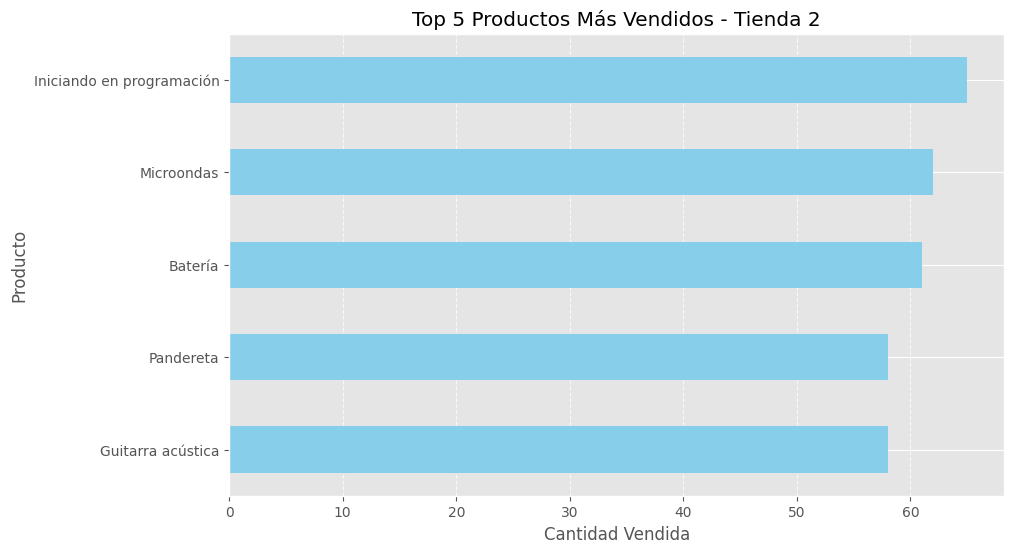

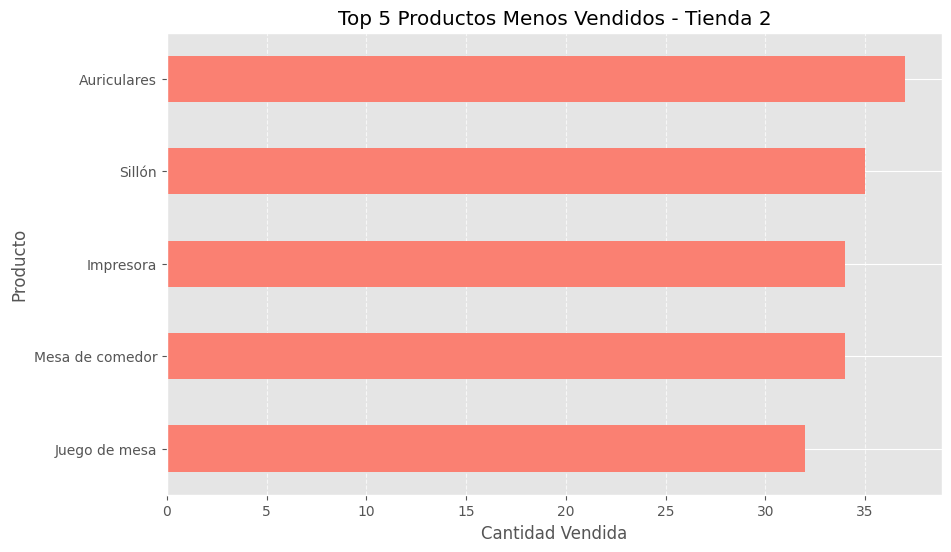


🏪 Tienda 3
----------------------------------------
🥇 Productos más vendidos en Tienda 3:
  Tienda        Producto  Cantidad_Vendida
Tienda 3   Kit de bancas                57
Tienda 3 Mesa de comedor                56
Tienda 3       Cama king                56
Tienda 3    Set de ollas                55
Tienda 3   Mesa de noche                55
🥉 Productos menos vendidos en Tienda 3:
  Tienda                Producto  Cantidad_Vendida
Tienda 3      Guitarra eléctrica                38
Tienda 3                 Mochila                36
Tienda 3              Microondas                36
Tienda 3            Set de vasos                36
Tienda 3 Bloques de construcción                35


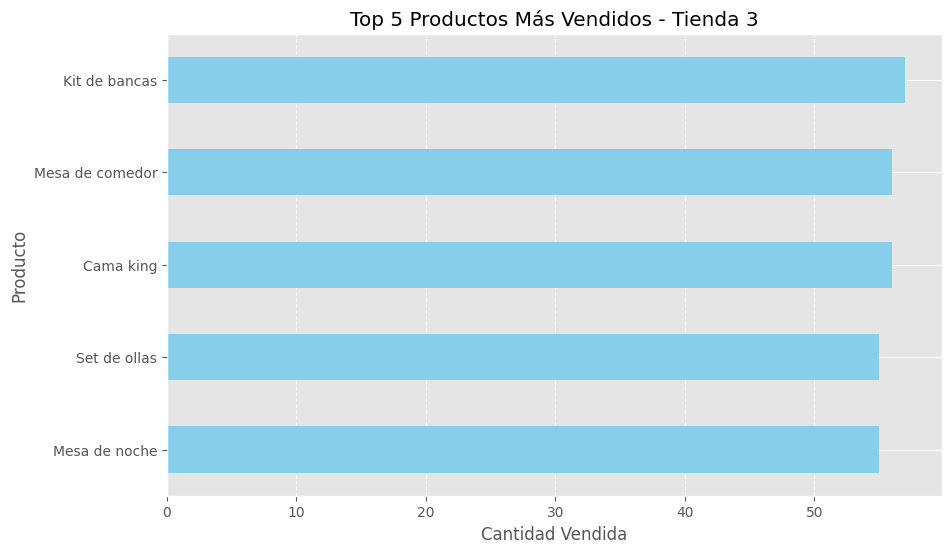

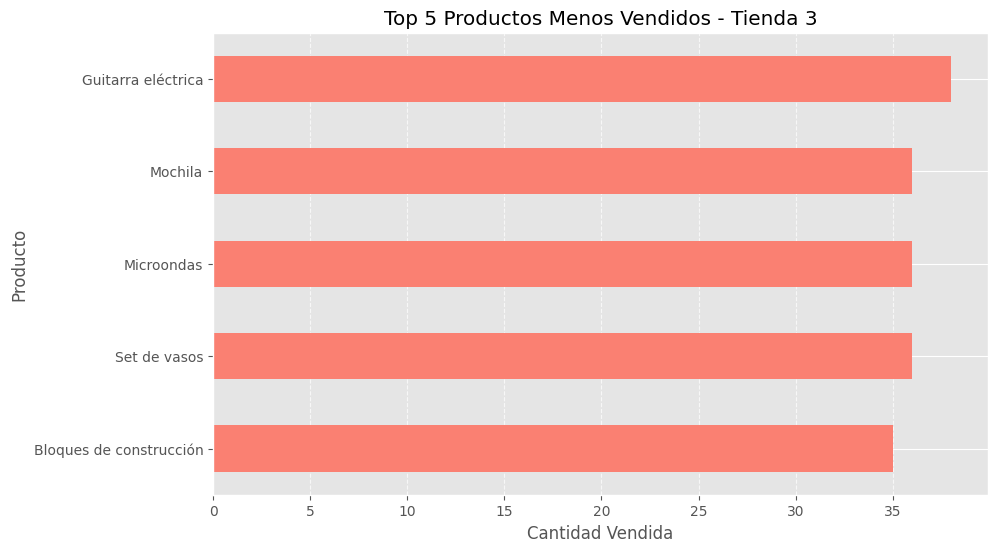


🏪 Tienda 4
----------------------------------------
🥇 Productos más vendidos en Tienda 4:
  Tienda                  Producto  Cantidad_Vendida
Tienda 4                  Cama box                62
Tienda 4                Cubertería                59
Tienda 4                 Cama king                56
Tienda 4   Dashboards con Power BI                56
Tienda 4 Carrito de control remoto                55
🥉 Productos menos vendidos en Tienda 4:
  Tienda                    Producto  Cantidad_Vendida
Tienda 4 Ciencia de datos con Python                38
Tienda 4                Refrigerador                38
Tienda 4           Guitarra acústica                37
Tienda 4                     Armario                34
Tienda 4          Guitarra eléctrica                33


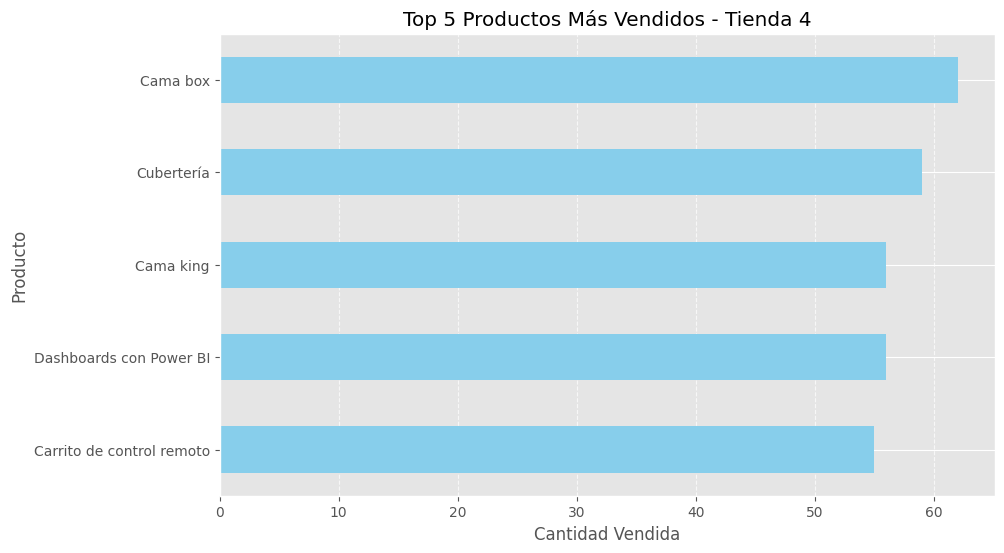

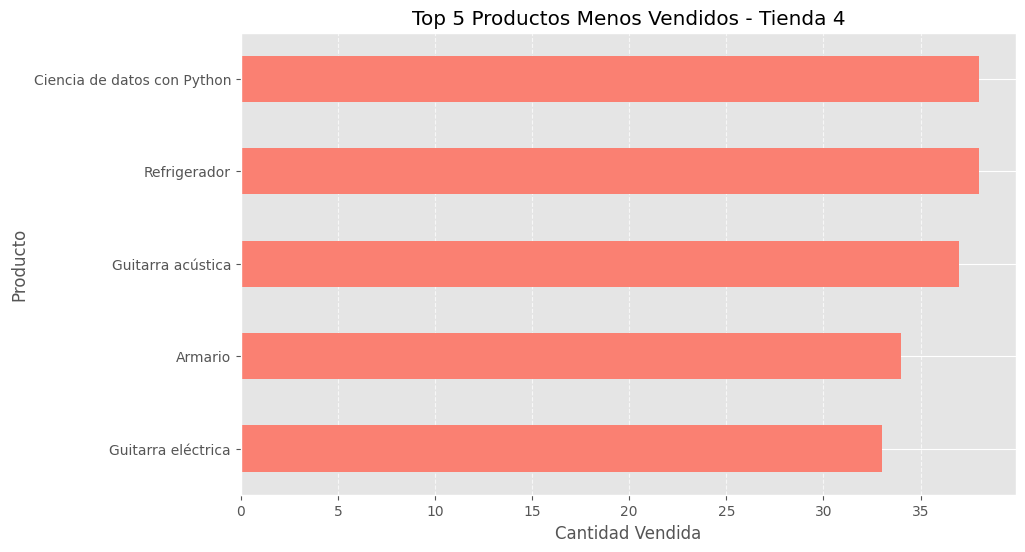

In [ ]:
import matplotlib.pyplot as plt

print("📈 ANÁLISIS DE PRODUCTOS MÁS Y MENOS VENDIDOS POR TIENDA")
print("="*60)

# Agrupar por Tienda y Producto para contar las ventas
ventas_por_producto_tienda = df_completo.groupby(['Tienda', 'Producto']).size().reset_index(name='Cantidad_Vendida')

# Analizar cada tienda individualmente y generar visualizaciones

for tienda_num in df_completo['Tienda'].unique():
    print(f"\n🏪 {tienda_num}")
    print("-" * 40)

    # Filtrar datos para la tienda actual
    datos_tienda = ventas_por_producto_tienda[ventas_por_producto_tienda['Tienda'] == tienda_num]

    # Ordenar por cantidad vendida
    productos_ordenados = datos_tienda.sort_values(by='Cantidad_Vendida', ascending=False)

    # Productos más vendidos (Top 5)
    mas_vendidos = productos_ordenados.head(5)
    print(f"🥇 Productos más vendidos en {tienda_num}:")
    print(mas_vendidos.to_string(index=False))

    # Productos menos vendidos (Bottom 5)
    menos_vendidos = productos_ordenados.tail(5)
    print(f"🥉 Productos menos vendidos en {tienda_num}:")
    print(menos_vendidos.to_string(index=False))

    # --- Visualización de los 5 productos más vendidos con pandas.plot() ---
    plt.figure(figsize=(10, 6))
    mas_vendidos.set_index('Producto')['Cantidad_Vendida'].plot(kind='barh', color='skyblue')
    plt.title(f'Top 5 Productos Más Vendidos - {tienda_num}')
    plt.xlabel('Cantidad Vendida')
    plt.ylabel('Producto')
    plt.gca().invert_yaxis() # Invertir el eje y para que el más vendido quede arriba
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

    # --- Visualización de los 5 productos menos vendidos con pandas.plot() ---
    plt.figure(figsize=(10, 6))
    menos_vendidos.set_index('Producto')['Cantidad_Vendida'].plot(kind='barh', color='salmon')
    plt.title(f'Top 5 Productos Menos Vendidos - {tienda_num}')
    plt.xlabel('Cantidad Vendida')
    plt.ylabel('Producto')
    plt.gca().invert_yaxis() # Invertir el eje y para que el menos vendido quede arriba
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

## 5. Costo de envío promedio por tienda

In [ ]:
# ============================================================
# ANÁLISIS 5: COSTO DE ENVÍO PROMEDIO POR TIENDA
# ============================================================

print("🚚 ANÁLISIS DE COSTO DE ENVÍO PROMEDIO")
print("="*60)

# Paso 1: Calcular el costo de envío promedio por tienda
costo_envio_promedio_por_tienda = df_completo.groupby('Tienda')['Costo de envío'].mean()

print("\n📈 Costo de envío promedio de cada tienda:")
print(costo_envio_promedio_por_tienda)

# Paso 2: Ordenar de mayor a menor
costo_envio_ordenado = costo_envio_promedio_por_tienda.sort_values(ascending=False)

print("\n🏆 Ranking de tiendas por costo de envío promedio:")
for i, (tienda, costo) in enumerate(costo_envio_ordenado.items(), 1):
    print(f"{i}. {tienda}: ${costo:,.2f}")

# Paso 3: Identificar la tienda con el MAYOR y MENOR costo de envío promedio
tienda_mayor_costo_envio = costo_envio_ordenado.idxmax()
mayor_costo = costo_envio_ordenado.max()

tienda_menor_costo_envio = costo_envio_ordenado.idxmin()
menor_costo = costo_envio_ordenado.min()

print(f"\n⬆️ Tienda con el MAYOR costo de envío promedio: {tienda_mayor_costo_envio} (${mayor_costo:,.2f})")
print(f"⬇️ Tienda con el MENOR costo de envío promedio: {tienda_menor_costo_envio} (${menor_costo:,.2f})")

🚚 ANÁLISIS DE COSTO DE ENVÍO PROMEDIO

📈 Costo de envío promedio de cada tienda:
Tienda
Tienda 1    26018.609580
Tienda 2    25216.235693
Tienda 3    24805.680373
Tienda 4    23459.457167
Name: Costo de envío, dtype: float64

🏆 Ranking de tiendas por costo de envío promedio:
1. Tienda 1: $26,018.61
2. Tienda 2: $25,216.24
3. Tienda 3: $24,805.68
4. Tienda 4: $23,459.46

⬆️ Tienda con el MAYOR costo de envío promedio: Tienda 1 ($26,018.61)
⬇️ Tienda con el MENOR costo de envío promedio: Tienda 4 ($23,459.46)


Visualizaciones

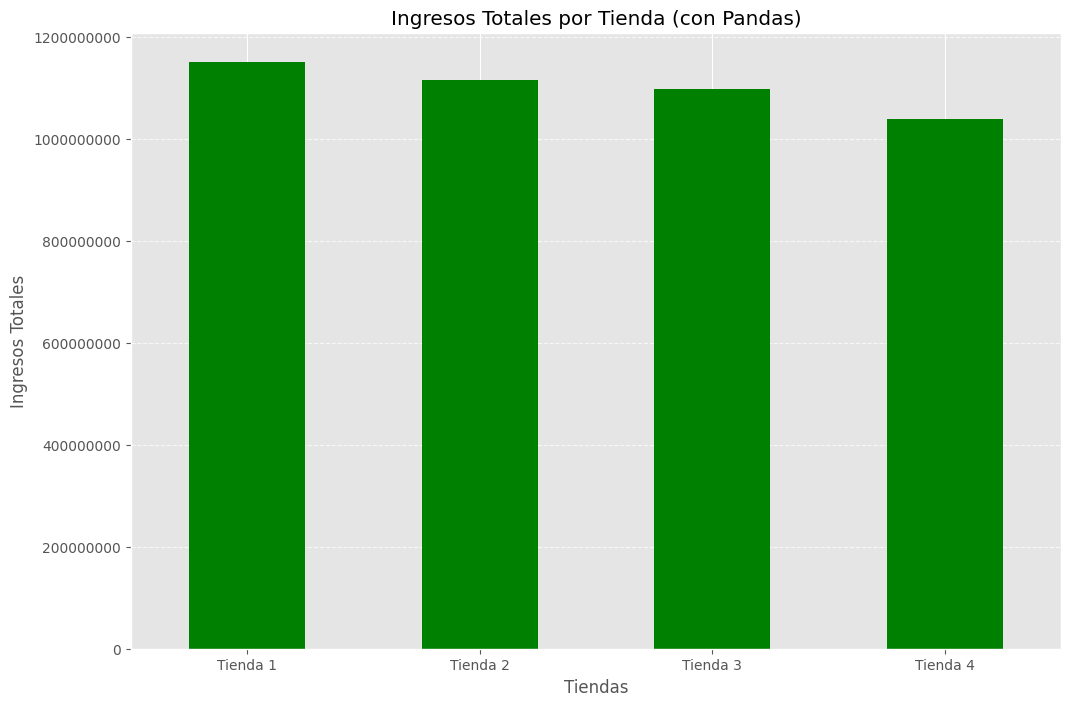

In [ ]:
import matplotlib.pyplot as plt

# El Series 'ingresos_por_tienda' ya está disponible

plt.figure(figsize=(12, 8))
ingresos_por_tienda.plot(kind='bar', color='green', xlabel='Tiendas', ylabel='Ingresos Totales', title='Ingresos Totales por Tienda (con Pandas)')
plt.ticklabel_format(style='plain', axis='y') # Para evitar la notación científica en el eje y
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

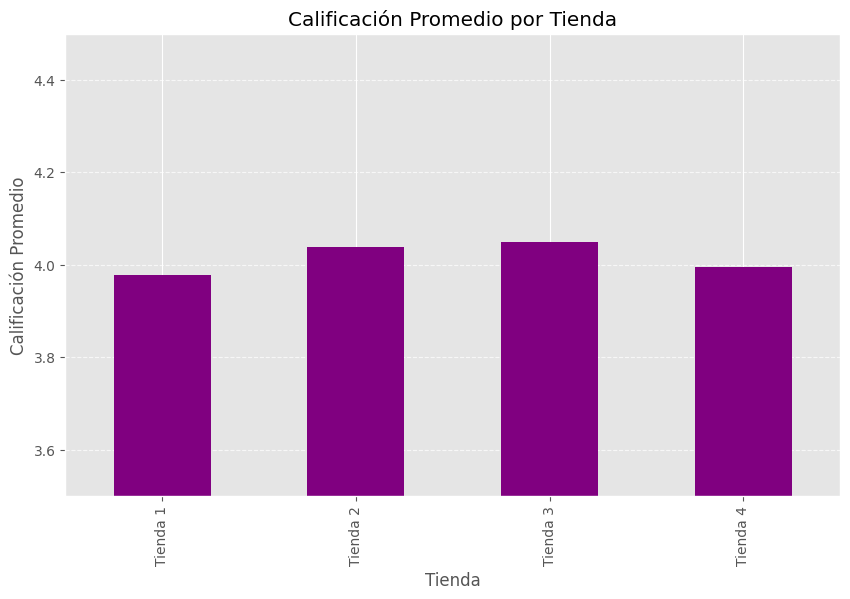

In [ ]:
import matplotlib.pyplot as plt

# Convert the Series to a DataFrame for plotting
calificaciones_df = calificacion_promedio_por_tienda.reset_index()
calificaciones_df.columns = ['Tienda', 'Calificación Promedio']

plt.figure(figsize=(10, 6))
calificacion_promedio_por_tienda.plot(kind='bar', color='purple')
plt.title('Calificación Promedio por Tienda')
plt.xlabel('Tienda')
plt.ylabel('Calificación Promedio')
plt.ylim(3.5, 4.5) # Set y-axis limits for better visualization of differences
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

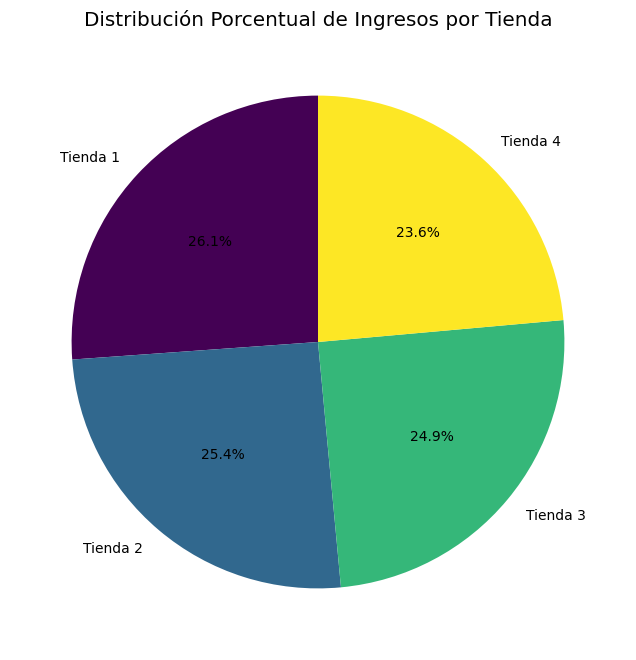

In [ ]:
import matplotlib.pyplot as plt

# El Series 'ingresos_por_tienda' ya está disponible

plt.figure(figsize=(10, 8))
ingresos_por_tienda.plot(kind='pie', autopct='%1.1f%%', startangle=90, cmap='viridis')
plt.title('Distribución Porcentual de Ingresos por Tienda')
plt.ylabel('') # Eliminar la etiqueta del eje y para gráficos de torta
plt.show()

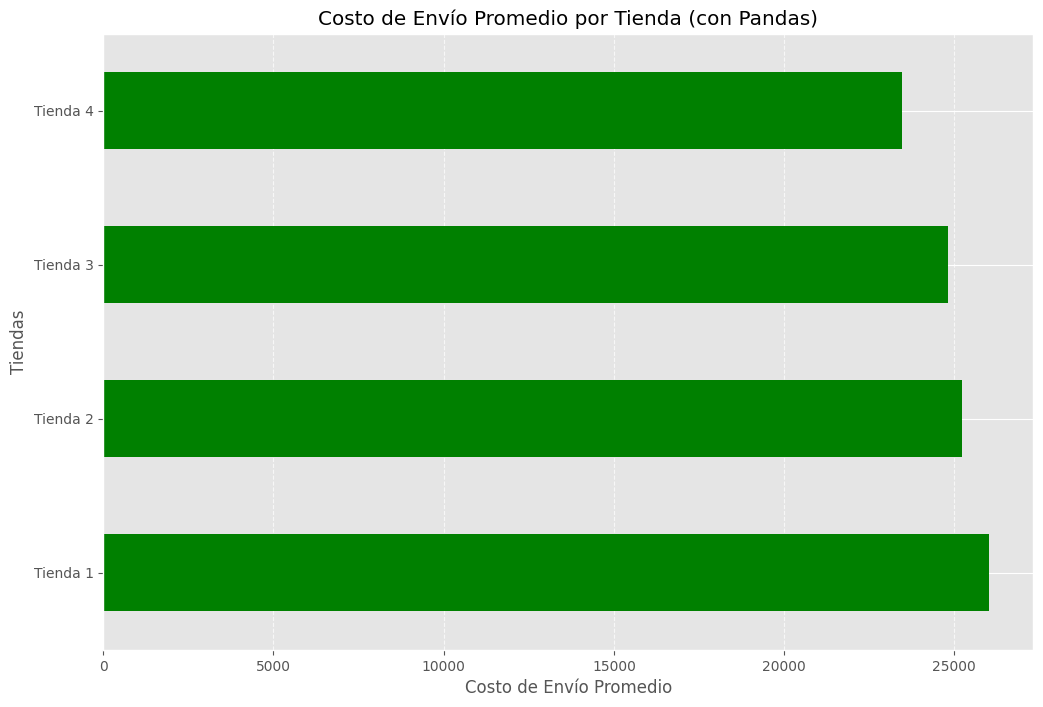

In [ ]:
import matplotlib.pyplot as plt

# Convert the Series to a DataFrame for plotting
costo_envio_df = costo_envio_promedio_por_tienda.reset_index()
costo_envio_df.columns = ['Tienda', 'Costo de Envío Promedio']

plt.figure(figsize=(12, 8))
costo_envio_promedio_por_tienda.plot(kind='barh', color='green', xlabel='Costo de Envío Promedio', ylabel='Tiendas', title='Costo de Envío Promedio por Tienda (con Pandas)')
plt.ticklabel_format(style='plain', axis='x') # To prevent scientific notation on x-axis for horizontal bar
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Informe Final: Análisis de Desempeño de Tiendas y Recomendación para el Sr. Juan

### Introducción
El objetivo de este informe es proporcionar un análisis exhaustivo del desempeño de las cuatro tiendas (Tienda 1, Tienda 2, Tienda 3, Tienda 4) basado en diversas métricas clave. A través de este análisis, se busca ofrecer una recomendación justificada al Sr. Juan sobre cuál tienda debería considerar vender, teniendo en cuenta factores financieros, de satisfacción del cliente y logísticos.

### Desarrollo de Análisis

#### 1. Ingresos Totales por Tienda
El análisis de ingresos totales revela la capacidad de cada tienda para generar ventas. Observamos la siguiente distribución de ingresos:

*   **Tienda 1:** $1,150,880,400
*   **Tienda 2:** $1,116,343,500
*   **Tienda 3:** $1,098,019,600
*   **Tienda 4:** $1,038,375,700

La **Tienda 1** lidera en ingresos totales, mostrando el mayor volumen de ventas, mientras que la **Tienda 4** se encuentra en el último lugar. Esto se visualiza claramente en el gráfico de 'Ingresos Totales por Tienda' generado anteriormente, donde la Tienda 1 destaca notablemente.

#### 2. Calificación Promedio de los Clientes
La calificación promedio de los clientes es un indicador directo de la satisfacción del cliente y la calidad percibida de los productos y servicios de cada tienda. Los promedios son:

*   **Tienda 3:** 4.05
*   **Tienda 2:** 4.04
*   **Tienda 4:** 4.00
*   **Tienda 1:** 3.98

La **Tienda 3** obtiene la mejor calificación promedio, lo que sugiere un alto nivel de satisfacción entre sus clientes. Contrariamente, la **Tienda 1**, a pesar de sus altos ingresos, registra la calificación promedio más baja. Este patrón es visible en el gráfico de 'Calificación Promedio por Tienda', donde se aprecian las diferencias, aunque sutiles, entre los promedios.

#### 3. Costo de Envío Promedio por Tienda
El costo de envío promedio es un factor logístico importante, especialmente considerando que el cliente paga el envío. Los costos promedio son:

*   **Tienda 1:** $26,018.61
*   **Tienda 2:** $25,216.24
*   **Tienda 3:** $24,805.68
*   **Tienda 4:** $23,459.46

La **Tienda 1** presenta el costo de envío promedio más alto, mientras que la **Tienda 4** tiene el más bajo. El gráfico de 'Costo de Envío Promedio por Tienda' ilustra estas variaciones, destacando que la Tienda 4 es la más eficiente o la que ofrece los envíos más económicos a sus clientes.

#### 4. Ventas por Categoría y Productos Más/Menos Vendidos

*   **Categorías de Productos:** 'Muebles' y 'Electrónicos' son consistentemente las categorías más vendidas en todas las tiendas, mientras que 'Artículos para el hogar' e 'Instrumentos musicales' suelen ser las de menor volumen, aunque esto varía ligeramente entre tiendas.

*   **Productos Específicos (Ejemplos):**
    *   **Tienda 1:** Los productos como 'Armario', 'TV LED UHD 4K' y 'Microondas' son top ventas, mientras que 'Auriculares con micrófono' y 'Celular ABXY' son de los menos vendidos.
    *   **Tienda 2:** 'Iniciando en programación' es un best-seller, mientras que 'Juego de mesa' es uno de los menos vendidos.
    *   **Tienda 3:** 'Kit de bancas', 'Mesa de comedor' y 'Cama king' tienen un buen desempeño, y 'Bloques de construcción' es de los menos populares.
    *   **Tienda 4:** 'Cama box' y 'Cubertería' son fuertes, pero 'Guitarra eléctrica' y 'Ciencia de datos con Python' están entre los menos vendidos.

Las visualizaciones de los 'Top 5 Productos Más Vendidos' y 'Top 5 Productos Menos Vendidos' por cada tienda ofrecen una visión detallada de estas tendencias.

### Conclusión y Recomendación

Al integrar todos los análisis, se observan contrastes importantes en el desempeño de las tiendas:

*   La **Tienda 1** es líder en ingresos, pero enfrenta desafíos con la satisfacción del cliente (calificación más baja) y los costos de envío (más altos). Esto podría indicar que su alto volumen de ventas no se traduce en una experiencia de cliente óptima, lo que podría afectar su sostenibilidad a largo plazo si no se abordan estas áreas.

*   La **Tienda 3** destaca por la excelente satisfacción del cliente, lo que es un activo valioso, aunque sus ingresos no son los más altos.

*   La **Tienda 4**, aunque tiene el costo de envío promedio más bajo, presenta los ingresos totales más bajos. Esto sugiere que, a pesar de una posible ventaja logística o de precios en envíos, no logra atraer un volumen de ventas suficiente para competir con las otras tiendas en términos financieros.

**Recomendación:**

Considerando que el Sr. Juan busca vender una tienda, la recomendación se basa en identificar la que presenta mayores desafíos financieros y de potencial de crecimiento. En este sentido, la **Tienda 4** es la candidata más apropiada para la venta.

**Justificación:**
Aunque la Tienda 1 tiene la calificación más baja y el envío más caro, sus ingresos son los más altos, lo que indica un fuerte poder de mercado que, con mejoras en la experiencia del cliente y la optimización de costos de envío, podría ser aún más rentable. Por otro lado, la **Tienda 4** muestra el desempeño financiero más débil (menores ingresos totales) y, aunque tiene un bajo costo de envío (lo cual es positivo), esto no se ha traducido en un volumen de ventas competitivo. Vender la Tienda 4 permitiría al Sr. Juan desinvertir en el activo de menor rendimiento financiero, y reenfocar recursos en las tiendas con mayor potencial de crecimiento o con fortalezas claras (como la Tienda 1 por sus ingresos o la Tienda 3 por su alta satisfacción del cliente).